<a href="https://colab.research.google.com/github/pavankumarpolu27/AIML_Pavan/blob/main/Low_Code_NLP_RAG_Project_Notebook_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

### Business Context

The healthcare industry is rapidly evolving, with professionals facing increasing challenges in managing vast volumes of medical data while delivering accurate and timely diagnoses. The need for quick access to comprehensive, reliable, and up-to-date medical knowledge is critical for improving patient outcomes and ensuring informed decision-making in a fast-paced environment.

Healthcare professionals often encounter information overload, struggling to sift through extensive research and data to create accurate diagnoses and treatment plans. This challenge is amplified by the need for efficiency, particularly in emergencies, where time-sensitive decisions are vital. Furthermore, access to trusted, current medical information from renowned manuals and research papers is essential for maintaining high standards of care.

To address these challenges, healthcare centers can focus on integrating systems that streamline access to medical knowledge, provide tools to support quick decision-making, and enhance efficiency. Leveraging centralized knowledge platforms and ensuring healthcare providers have continuous access to reliable resources can significantly improve patient care and operational effectiveness.

**Common Questions to Answer**

**1. Diagnostic Assistance**: "What are the common symptoms and treatments for pulmonary embolism?"

**2. Drug Information**: "Can you provide the trade names of medications used for treating hypertension?"

**3. Treatment Plans**: "What are the first-line options and alternatives for managing rheumatoid arthritis?"

**4. Specialty Knowledge**: "What are the diagnostic steps for suspected endocrine disorders?"

**5. Critical Care Protocols**: "What is the protocol for managing sepsis in a critical care unit?"

### Objective

As an AI specialist, your task is to develop a RAG-based AI solution using renowned medical manuals to address healthcare challenges. The objective is to **understand** issues like information overload, **apply** AI techniques to streamline decision-making, **analyze** its impact on diagnostics and patient outcomes, **evaluate** its potential to standardize care practices, and **create** a functional prototype demonstrating its feasibility and effectiveness.

### Data Description

The **Merck Manuals** are medical references published by the American pharmaceutical company Merck & Co., that cover a wide range of medical topics, including disorders, tests, diagnoses, and drugs. The manuals have been published since 1899, when Merck & Co. was still a subsidiary of the German company Merck.

The manual is provided as a PDF with over 4,000 pages divided into 23 sections.

## **Please read the instructions carefully before starting the project.**

This is a commented Python Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_____' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_____' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same. Any mathematical or computational details which are a graded part of the project can be included in the Appendix section of the presentation.

**Note**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:

1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.

2. Switch to a different Google account and resume working on the project from there.

3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

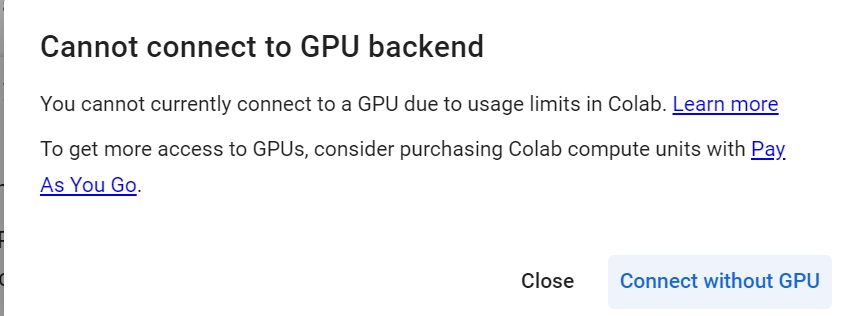

## Installing and Importing Necessary Libraries and Dependencies

In [ ]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.2.28 --force-reinstall --no-cache-dir -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
# !CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python==0.2.28 --force-reinstall --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 44.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 326.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 314.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 260.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 257.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.5 which is incompatible.
opencv-contrib-python 4.12.

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# For installing the libraries & downloading models from HF Hub
!pip install huggingface_hub==0.35.3 pandas==2.2.2 tiktoken==0.12.0 pymupdf==1.26.5 langchain==0.3.27 langchain-community==0.3.31 chromadb==1.1.1 sentence-transformers==5.1.1 numpy==2.3.3 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 6.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.6/486.6 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 89.2 MB/s eta 0

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
#Libraries for downloading and loading the llm
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

## Question Answering using LLM

### Downloading and Loading the model

In [ ]:
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"

In [ ]:
model_path = hf_hub_download(
    repo_id= "TheBloke/Mistral-7B-Instruct-v0.2-GGUF", #Complete the code to mention the repo id
    filename= "mistral-7b-instruct-v0.2.Q6_K.gguf" #Complete the code to mention the model name
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


mistral-7b-instruct-v0.2.Q6_K.gguf:   0%|          | 0.00/5.94G [00:00<?, ?B/s]

In [ ]:
#uncomment the below snippet of code if the runtime is connected to GPU.
llm = Llama(
    model_path=model_path,
    n_ctx=2300,
    n_gpu_layers=38,
    n_batch=512
)

AVX = 1 | AVX_VNNI = 0 | AVX2 = 1 | AVX512 = 0 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 1 | SSE3 = 1 | SSSE3 = 1 | VSX = 0 | 


In [ ]:
#uncomment the below snippet of code if the runtime is connected to CPU only.
#llm = Llama(
#    model_path=model_path,
#    n_ctx=1024,
#    n_cores=-2
#)

### Response

In [ ]:
def response(query,max_tokens=128,temperature=0,top_p=0.95,top_k=50):
    model_output = llm(
      prompt=query,
      max_tokens=max_tokens,
      temperature=temperature,
      top_p=top_p,
      top_k=top_k
    )

    return model_output['choices'][0]['text']

In [ ]:
response("What treatment options are available for managing hypertension?")

'\n\nHypertension, or high blood pressure, is a common condition that can increase the risk of various health problems such as heart disease, stroke, and kidney damage. The good news is that there are several effective treatment options available to help manage hypertension and reduce the risk of complications. Here are some of the most commonly used treatments:\n\n1. Lifestyle modifications: Making lifestyle changes is often the first line of defense against hypertension. This may include eating a healthy diet rich in fruits, vegetables, whole grains, and lean proteins; limiting sodium intake; getting regular physical activity'

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
user_input = "What is the protocol for managing sepsis in a critical care unit?"
response(user_input)

Llama.generate: prefix-match hit


'\n\nSepsis is a life-threatening condition that can arise from an infection, and it requires prompt recognition and aggressive management in a critical care unit. The following are general steps for managing sepsis in a critical care unit:\n\n1. Early recognition: Recognize the signs and symptoms of sepsis early and initiate treatment as soon as possible. Sepsis can present with various clinical features, including fever or hypothermia, tachycardia or bradycardia, altered mental status, respiratory distress, and lactic acidosis.\n2. ABCs'

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to define the query #2
response(user_input_2) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'\n\nAppendicitis is a medical condition characterized by inflammation of the appendix, a small pouch-like structure that extends from the large intestine. The symptoms of appendicitis can vary from person to person, but some common signs include:\n\n1. Abdominal pain: The pain is typically located in the lower right side of the abdomen and may be constant or come and go. It may start as a mild discomfort that worsens over time.\n2. Loss of appetite: People with appendicitis often lose their appetite due to abdominal pain and nausea'

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
user_input_3 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to define the query #3
response(user_input_3) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nSudden patchy hair loss, also known as alopecia areata, is a common autoimmune disorder that affects the hair follicles. It can result in round or oval bald patches on the scalp, but it can also occur on other parts of the body such as the beard area, eyebrows, and eyelashes.\n\nThe exact cause of alopecia areata is not known, but it's believed to be related to a problem with the immune system. Some possible triggers for this condition include stress, genetics, viral infections, and certain medications."

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
user_input_4 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to define the query #4
response(user_input_4) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'\n\nA person who has sustained a physical injury to the brain tissue may require various treatments depending on the severity and location of the injury. Here are some common treatments that may be recommended:\n\n1. Emergency care: In case of a traumatic brain injury (TBI), it is essential to seek emergency medical attention as soon as possible. The primary goal of emergency care is to prevent further damage to the brain, stabilize vital signs, and manage any life-threatening conditions.\n2. Medications: Depending on the symptoms, healthcare professionals may prescribe medications to manage various conditions associated with a'

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
user_input_5 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to define the query #5
response(user_input_5) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nFirst and foremost, if you suspect that someone has fractured their leg while hiking, it's essential to ensure their safety and prevent further injury. Here are some necessary precautions:\n\n1. Keep the person calm and still: Encourage them to remain as still as possible to minimize pain and prevent worsening the injury.\n2. Assess the situation: Check for any signs of shock, such as pale skin, rapid heartbeat, or shallow breathing. If you notice these symptoms, seek medical help immediately.\n3. Immobilize the leg: Use a splint, sl"

## Question Answering using LLM with Prompt Engineering

In [ ]:
system_prompt = "You are a helpful and knowledgeable medical assistant. Provide clear, accurate, and concise responses to medical queries based on best practices and current clinical guidelines." #Complete the code to define the system prompt

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
user_input = system_prompt+"\n"+ "What is the protocol for managing sepsis in a critical care unit?"
response(user_input)

Llama.generate: prefix-match hit


'\nSepsis is a life-threatening condition caused by a dysregulated response to infection. In a critical care unit, managing sepsis involves a multidisciplinary approach that focuses on early recognition, prompt initiation of appropriate antibiotics, fluid resuscitation, and supportive measures to maintain organ function. Here are the key steps in managing sepsis in a critical care unit:\n1. Early Recognition: Identify sepsis suspects based on clinical suspicion, laboratory findings (such as leukocytosis or leukopenia, lactate level >2 mmol'

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
user_input = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to pass the query #2
response(user_input) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'\n\nAppendicitis is a medical condition characterized by inflammation of the appendix, a small tube-shaped organ located in the lower right side of the abdomen. The symptoms of appendicitis can vary from person to person, but some common signs include:\n\n1. Abdominal pain: The pain typically starts as a mild discomfort around the navel or in the lower right abdomen. It may then move to the right lower quadrant and become more severe over time. The pain is often described as sharp, crampy, or constant.\n2. Loss of appetite: People with'

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
user_input = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to pass the query #3
response(user_input) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nSudden patchy hair loss, also known as alopecia areata, is a common autoimmune disorder that affects the hair follicles. It can result in round or oval bald patches on the scalp, but it can also occur on other parts of the body such as the beard area, eyebrows, or eyelashes.\n\nThe exact cause of alopecia areata is not known, but it's believed to be related to a problem with the immune system. Some possible triggers for this condition include stress, genetics, viral infections, and certain medications."

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
user_input = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to pass the query #4
response(user_input) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'\n\nA person who has sustained a physical injury to the brain tissue may require various treatments depending on the severity and location of the injury. Here are some common treatments that may be recommended:\n\n1. Emergency care: In case of a traumatic brain injury (TBI), it is essential to seek emergency medical attention as soon as possible. The primary goal of emergency care is to prevent further damage to the brain, stabilize vital signs, and manage any life-threatening conditions.\n2. Medications: Depending on the symptoms, healthcare professionals may prescribe medications to manage various conditions associated with a'

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
user_input = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to pass the query #5
response(user_input) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"\n\nFirst and foremost, if you suspect that someone has fractured their leg while hiking, it's essential to ensure their safety and prevent further injury. Here are some necessary precautions:\n\n1. Keep the person calm and still: Encourage them to remain as still as possible to minimize pain and prevent worsening the injury.\n2. Assess the situation: Check for any signs of shock, such as pale skin, rapid heartbeat, or shallow breathing. If you notice these symptoms, seek medical help immediately.\n3. Immobilize the leg: Use a splint, sl"

## Data Preparation for RAG

In [ ]:
#Libraries for processing dataframes,text
import json,os
import tiktoken
import pandas as pd

#Libraries for Loading Data, Chunking, Embedding, and Vector Databases
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_community.embeddings.sentence_transformer import SentenceTransformerEmbeddings
from langchain_community.vectorstores import Chroma

### Loading the Data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
manual_pdf_path = "/content/sample_data/medical_diagnosis_manual.pdf" #Complete the code to define the file name

In [ ]:
pdf_loader = PyMuPDFLoader(manual_pdf_path)

In [ ]:
manual = pdf_loader.load()

### Data Overview

#### Checking the first 5 pages

In [ ]:
for i in range(5):
    print(f"Page Number : {i+1}",end="\n")
    print(manual[i].page_content,end="\n")

Page Number : 1
pavan355@gmail.com
AKMQWUTG53
eant for personal use by pavan355@gm
shing the contents in part or full is liable
Page Number : 2
pavan355@gmail.com
AKMQWUTG53
This file is meant for personal use by pavan355@gmail.com only.
Sharing or publishing the contents in part or full is liable for legal action.
Page Number : 3
Table of Contents
1
Front    ................................................................................................................................................................................................................
1
Cover    .......................................................................................................................................................................................................
2
Front Matter    ...........................................................................................................................................................................................
53
1 - Nutri

#### Checking the number of pages

In [ ]:
len(manual)

4114

### Data Chunking

In [ ]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=1000, #Complete the code to define the chunk size
    chunk_overlap= 200 #Complete the code to define the chunk overlap
)

In [ ]:
document_chunks = pdf_loader.load_and_split(text_splitter)

In [ ]:
len(document_chunks)

4657

In [ ]:
document_chunks[0].page_content

'pavan355@gmail.com\nAKMQWUTG53\neant for personal use by pavan355@gm\nshing the contents in part or full is liable'

In [ ]:
document_chunks[2].page_content

"Table of Contents\n1\nFront    ................................................................................................................................................................................................................\n1\nCover    .......................................................................................................................................................................................................\n2\nFront Matter    ...........................................................................................................................................................................................\n53\n1 - Nutritional Disorders    ...............................................................................................................................................................\n53\nChapter 1. Nutrition: General Considerations    ...........................................................................................

In [ ]:
document_chunks[3].page_content

'491\nChapter 44. Foot & Ankle Disorders    .....................................................................................................................................\n502\nChapter 45. Tumors of Bones & Joints    ...............................................................................................................................\n510\n5 - Ear, Nose, Throat & Dental Disorders    ..................................................................................................................\n510\nChapter 46. Approach to the Patient With Ear Problems    ...........................................................................................\n523\nChapter 47. Hearing Loss    .........................................................................................................................................................\n535\nChapter 48. Inner Ear Disorders    ...................................................................................................

As expected, there are some overlaps

### Embedding

In [ ]:
embedding_model = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2") #Complete the code to define the model name

/tmp/ipython-input-2254781219.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2") #Complete the code to define the model name


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embedding_1 = embedding_model.embed_query(document_chunks[0].page_content)
embedding_2 = embedding_model.embed_query(document_chunks[1].page_content)

In [ ]:
print("Dimension of the embedding vector ",len(embedding_1))
len(embedding_1)==len(embedding_2)

Dimension of the embedding vector  384


True

In [ ]:
embedding_1,embedding_2

([-0.08221236616373062,
  0.07698830962181091,
  0.06238454207777977,
  -0.04755323752760887,
  0.05402231588959694,
  -0.020432617515325546,
  0.10097470879554749,
  0.04559898003935814,
  -0.010984834283590317,
  0.0014077514642849565,
  0.07181381434202194,
  -0.004328946582973003,
  0.01478489488363266,
  -0.0761570930480957,
  -0.05337708815932274,
  -0.07565958797931671,
  -0.06248500198125839,
  -0.0072443862445652485,
  -0.06592298299074173,
  -0.015090389177203178,
  -0.054484300315380096,
  -0.008607913739979267,
  -0.018284356221556664,
  -0.016126256436109543,
  -0.0360652320086956,
  0.04728049039840698,
  -0.018539881333708763,
  0.0651855319738388,
  -0.0031694385688751936,
  -0.06660405546426773,
  0.03853818401694298,
  -0.020170046016573906,
  0.005922984331846237,
  -0.0030859773978590965,
  0.03558912128210068,
  0.059671733528375626,
  -0.08983204513788223,
  -0.05059077590703964,
  -0.019551848992705345,
  -0.06670909374952316,
  -0.010819194838404655,
  -0.070561

### Vector Database

In [ ]:
out_dir = 'medical_db'

if not os.path.exists(out_dir):
  os.makedirs(out_dir)

In [ ]:
vectorstore = Chroma.from_documents(
    documents=document_chunks, #Complete the code to pass the document chunks
    embedding=embedding_model, #Complete the code to pass the embedding model
    persist_directory=out_dir
)

In [ ]:
vectorstore = Chroma(persist_directory=out_dir,embedding_function=embedding_model)

/tmp/ipython-input-2756559696.py:1: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(persist_directory=out_dir,embedding_function=embedding_model)


In [ ]:
vectorstore.embeddings

HuggingFaceEmbeddings(client=SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
), model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, multi_process=False, show_progress=False)

In [ ]:
vectorstore.similarity_search("What are the symptoms of appendicitis?", k=3) #Complete the code to pass a query and an appropriate k value

[Document(metadata={'file_path': '/content/sample_data/medical_diagnosis_manual.pdf', 'keywords': '', 'subject': '', 'creationdate': '2012-06-15T05:44:40+00:00', 'page': 173, 'creationDate': 'D:20120615054440Z', 'format': 'PDF 1.7', 'author': '', 'creator': 'Atop CHM to PDF Converter', 'trapped': '', 'source': '/content/sample_data/medical_diagnosis_manual.pdf', 'title': 'The Merck Manual of Diagnosis & Therapy, 19th Edition', 'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'modDate': 'D:20251202032207Z', 'total_pages': 4114, 'moddate': '2025-12-02T03:22:07+00:00'}, page_content="Etiology\nAppendicitis is thought to result from obstruction of the appendiceal lumen, typically by lymphoid\nhyperplasia, but occasionally by a fecalith, foreign body, or even worms. The obstruction leads to\ndistention, bacterial overgrowth, ischemia, and inflammation. If untreated, necrosis, gangrene, and\nperforation occur. If the perforation is contained by the omentum, an appendiceal abscess 

### Retriever

In [ ]:
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 3} #Complete the code to pass an appropriate k value
)

In [ ]:
rel_docs = retriever.get_relevant_documents("What are the symptoms of appendicitis?") #Complete the code to pass the query
rel_docs

/tmp/ipython-input-3739164762.py:1: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  rel_docs = retriever.get_relevant_documents("What are the symptoms of appendicitis?") #Complete the code to pass the query


[Document(metadata={'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'modDate': 'D:20251202032207Z', 'trapped': '', 'title': 'The Merck Manual of Diagnosis & Therapy, 19th Edition', 'source': '/content/sample_data/medical_diagnosis_manual.pdf', 'moddate': '2025-12-02T03:22:07+00:00', 'format': 'PDF 1.7', 'author': '', 'file_path': '/content/sample_data/medical_diagnosis_manual.pdf', 'keywords': '', 'creator': 'Atop CHM to PDF Converter', 'creationDate': 'D:20120615054440Z', 'creationdate': '2012-06-15T05:44:40+00:00', 'total_pages': 4114, 'page': 173, 'subject': ''}, page_content="Etiology\nAppendicitis is thought to result from obstruction of the appendiceal lumen, typically by lymphoid\nhyperplasia, but occasionally by a fecalith, foreign body, or even worms. The obstruction leads to\ndistention, bacterial overgrowth, ischemia, and inflammation. If untreated, necrosis, gangrene, and\nperforation occur. If the perforation is contained by the omentum, an appendiceal abscess 

In [ ]:
model_output = llm(
      "What are the symptoms of appendicitis?", #Complete the code to pass the query
      max_tokens=256, #Complete the code to pass the maximum number of tokens
      temperature=0.7, #Complete the code to pass the temperature
    )

Llama.generate: prefix-match hit


In [ ]:
model_output['choices'][0]['text']

'\n\nAppendicitis is a medical condition characterized by inflammation of the appendix, a small tube-shaped organ that extends from the large intestine. The most common symptom of appendicitis is sudden onset of pain in the lower right side of the abdomen. Other symptoms may include:\n\n1. Loss of appetite and feeling sick to your stomach\n2. Nausea and vomiting\n3. Fever, which may be low-grade at first but can rise as high as 103 degrees Fahrenheit (39.4 degrees Celsius)\n4. Diarrhea or constipation\n5. Abdominal swelling and bloating\n6. Pain that worsens when walking, coughing, sneezing, or making other sudden movements\n7. Pain that is relieved by lying down or applying pressure to the area\n8. Inability to pass gas or have a bowel movement\n9. Feeling restless or unable to get comfortable\n10. Increased heart rate and rapid breathing\n\nAppendicitis can be a medical emergency, as the appendix can rupture and cause peritonitis, an infection of the abdominal'

The above response is somewhat generic and is solely based on the data the model was trained on, rather than the medical manual.  

Let's now provide our own context.

### System and User Prompt Template

Prompts guide the model to generate accurate responses. Here, we define two parts:

    1. The system message describing the assistant's role.
    2. A user message template including context and the question.

In [ ]:
qna_system_message = "You are a knowledgeable and helpful medical assistant. Provide accurate, concise, and empathetic answers to health-related questions based on current clinical guidelines."  #Complete the code to define the system message

In [ ]:
qna_user_message_template = "{question}" #Complete the code to define the user message

### Response Function

In [ ]:
def generate_rag_response(user_input,k=3,max_tokens=128,temperature=0,top_p=0.95,top_k=50):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=k)
    context_list = [d.page_content for d in relevant_document_chunks]

    # Combine document chunks into a single context
    context_for_query = ". ".join(context_list)

    user_message = qna_user_message_template.replace('{context}', context_for_query)
    user_message = user_message.replace('{question}', user_input)

    prompt = qna_system_message + '\n' + user_message

    # Generate the response
    try:
        response = llm(
                  prompt=prompt,
                  max_tokens=max_tokens,
                  temperature=temperature,
                  top_p=top_p,
                  top_k=top_k
                  )

        # Extract and print the model's response
        response = response['choices'][0]['text'].strip()
    except Exception as e:
        response = f'Sorry, I encountered the following error: \n {e}'

    return response

## Question Answering using RAG

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
user_input = "What is the protocol for managing sepsis in a critical care unit?"
generate_rag_response(user_input,top_k=20)

Llama.generate: prefix-match hit


'Sepsis is a life-threatening condition caused by a dysregulated response to infection. In a critical care unit, managing sepsis involves prompt recognition, immediate intervention, and ongoing supportive care. Here are the key steps:\n1. Recognition: Look for signs of infection, such as fever, chills, or infection site, along with systemic inflammatory response syndrome (SIRS) symptoms, like tachycardia, tachypnea, altered mental status, and lactic acidosis. Use the Sequential Organ Failure Assessment (SOFA) score to'

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to pass the query #2
generate_rag_response(user_input_2, top_k=20) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'Appendicitis is a medical condition characterized by inflammation of the appendix, a small pouch located in the lower right side of the abdomen. Common symptoms include:\n1. Sudden and persistent pain in the lower right abdomen that may start around the navel and then shift to the right side.\n2. Loss of appetite and feeling sick to your stomach (nausea).\n3. Fever, which may be low-grade at first but can rise as high as 101°F (38.3°C) or more.\n4. Vomiting'

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
user_input_2 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to pass the query #3
generate_rag_response(user_input_2, top_k=20) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"Sudden patchy hair loss, also known as alopecia areata, is an autoimmune condition that causes hair loss in small, round patches on the scalp or other areas of the body. The exact cause of alopecia areata is not known, but it's believed to be related to a problem with the immune system.\nThere are several treatments for addressing sudden patchy hair loss:\n1. Corticosteroids: These medications can be applied directly to the affected area or taken orally to reduce inflammation and suppress the immune response that causes hair loss.\n2."

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
user_input_2 = " What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to pass the query #4
generate_rag_response(user_input_2, top_k=20) #Complete the code to pass the user input

Llama.generate: prefix-match hit


'A person with a brain injury may require a combination of medical interventions and rehabilitative therapies depending on the severity and location of the injury. Here are some common treatments:\n\n1. Emergency care: For severe brain injuries, immediate medical attention is necessary to prevent further damage or complications. This may include surgery to remove hematomas or decompressing skull fractures, administering medications to manage swelling or seizures, and providing supportive care such as ventilation and fluid replacement.\n2. Medications: Depending on the symptoms, various medications may be prescribed to manage conditions associated with'

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
user_input_2 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to pass the query #5
generate_rag_response(user_input_2, top_k=20) #Complete the code to pass the user input

Llama.generate: prefix-match hit


"A fractured leg, also known as a broken leg, is a common injury that can occur during physical activities like hiking. Here are some necessary precautions and treatment steps for someone who has sustained this type of injury:\n1. Assess the severity of the injury: If you suspect a fracture, do not move the person unless it's necessary to prevent further harm or ensure their safety. Look for signs of swelling, bruising, deformity, and inability to bear weight on the affected leg.\n2. Call for emergency medical help if necessary: If the injury is severe, such"

### Fine-tuning

#### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
user_input = "What is the protocol for managing sepsis in a critical care unit?"
generate_rag_response(user_input,temperature=0.5)

Llama.generate: prefix-match hit


'Sepsis is a life-threatening condition caused by a dysregulated response to infection. In a critical care unit, the management of sepsis involves prompt recognition and initiation of appropriate interventions to prevent progression to septic shock. Here are the key steps in managing sepsis in a critical care unit:\n1. Early recognition: Recognize the signs and symptoms of sepsis early and initiate treatment as soon as possible. Look for symptoms such as fever, chills, rapid heart rate, rapid breathing, low blood pressure, confusion, and decreased urine output.\n2'

#### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to pass the query #2
generate_rag_response(user_input_2,temperature=0.5) #Complete the code to pass the user input along with the parameters

Llama.generate: prefix-match hit


'Appendicitis is a medical condition characterized by inflammation of the appendix, a small pouch located in the lower right side of the abdomen. The symptoms of appendicitis typically include:\n\n1. Sudden and persistent pain in the lower right abdomen, which may begin as mild but soon becomes severe and constant.\n2. Loss of appetite, feeling sick to your stomach (nausea), or vomiting.\n3. Fever, often above 101°F (38.3°C).\n4. Abdominal swelling and rigidity,'

#### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
user_input_2 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to pass the query #3
generate_rag_response(user_input_2,temperature=0.5) #Complete the code to pass the user input along with the parameters

Llama.generate: prefix-match hit


"Sudden patchy hair loss, also known as alopecia areata, is an autoimmune condition that causes hair loss in small, round patches on the scalp or other areas of the body. The exact cause is unknown, but it's believed to be related to a problem with the immune system attacking the hair follicles.\nThere are several treatments that may help stimulate hair growth and prevent further hair loss:\n1. Corticosteroids: These medications can be applied directly to the affected area or taken orally. They work by reducing inflammation and suppressing the immune response."

#### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
user_input_2 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to pass the query #4
generate_rag_response(user_input_2,temperature=0.5) #Complete the code to pass the user input along with the parameters

Llama.generate: prefix-match hit


"I'm glad you asked about treatments for brain injuries. The specific treatment depends on the severity and location of the injury. For mild traumatic brain injuries (TBIs), also known as concussions, rest, hydration, and avoiding activities that worsen symptoms are typically recommended. More severe TBIs may require hospitalization, surgery, or rehabilitation to address any life-threatening conditions and promote recovery. Rehabilitation programs often include physical therapy, occupational therapy, speech therapy, and cognitive rehabilitation to help individuals regain lost skills and improve overall function. Medications"

#### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
user_input_2 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to pass the query #5
generate_rag_response(user_input_2,temperature=0.5) #Complete the code to pass the user input along with the parameters

Llama.generate: prefix-match hit


'A leg fracture sustained during a hiking trip requires prompt medical attention. Here are some necessary precautions and treatment steps:\n1. Immediate first aid: Apply a sterile dressing to the injury site if it is open or bleeding. Do not try to realign the bone or apply excessive pressure on the affected area. Use a splint, sling, or other immobilizing device to keep the leg stable and prevent further damage.\n2. Transportation: If the person is unable to walk or bear weight on the affected leg, arrange for transportation to the nearest emergency room or healthcare facility. Do not attempt'

## Output Evaluation

Let us now use the LLM-as-a-judge method to check the quality of the RAG system on two parameters - retrieval and generation.

- We are using the same Mistral model for evaluation, so basically here the llm is rating itself on how well he has performed in the task.

In [ ]:
groundedness_rater_system_message = "You are an expert evaluator. Assess whether the answer is grounded in the provided context. Respond with 'Yes' or 'No' and briefly explain your reasoning." #Complete the code to define the prompt to evaluate groundedness

In [ ]:
relevance_rater_system_message = "You are an expert evaluator. Assess whether the answer is relevant to the question. Respond with 'Yes' or 'No' and briefly explain your reasoning." #Complete the code to define the prompt to evaluate relevance

In [ ]:
user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

In [ ]:
def generate_ground_relevance_response(user_input,k=3,max_tokens=128,temperature=0,top_p=0.95,top_k=50):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks for the main answer generation
    relevant_document_chunks_for_rag = retriever.get_relevant_documents(query=user_input,k=k)
    context_list_for_rag = [d.page_content for d in relevant_document_chunks_for_rag]
    context_for_rag_query = ". ".join(context_list_for_rag)

    # Construct the user message for the main RAG response
    user_message_rag = qna_user_message_template.replace('{context}', context_for_rag_query)
    user_message_rag = user_message_rag.replace('{question}', user_input)

    prompt_rag = qna_system_message + '\n' + user_message_rag

    # Generate the main RAG response
    try:
        rag_response = llm(
                  prompt=prompt_rag,
                  max_tokens=max_tokens,
                  temperature=temperature,
                  top_p=top_p,
                  top_k=top_k
                  )

        answer = rag_response['choices'][0]['text'].strip()
    except Exception as e:
        answer = f'Sorry, I encountered the following error during RAG response generation: \n {e}'

    # Retrieve relevant document chunks for evaluation (reducing k to fit context window)
    relevant_document_chunks_for_eval = retriever.get_relevant_documents(query=user_input, k=1)
    context_list_for_eval = [d.page_content for d in relevant_document_chunks_for_eval]
    context_for_eval_query = ". ".join(context_list_for_eval)


    # Combine user_prompt and system_message to create the prompt for groundedness evaluation
    groundedness_prompt = f"""[INST]{groundedness_rater_system_message}\n
                {'user'}: {user_message_template.format(context=context_for_eval_query, question=user_input, answer=answer)}
                [/INST]"""

    # Combine user_prompt and system_message to create the prompt for relevance evaluation
    relevance_prompt = f"""[INST]{relevance_rater_system_message}\n
                {'user'}: {user_message_template.format(context=context_for_eval_query, question=user_input, answer=answer)}
                [/INST]"""

    try:
        response_1 = llm(
                prompt=groundedness_prompt,
                max_tokens=max_tokens,
                temperature=temperature,
                top_p=top_p,
                top_k=top_k,
                stop=['INST'],
                echo=False
                )
        groundedness_evaluation = response_1['choices'][0]['text'].strip()
    except Exception as e:
        groundedness_evaluation = f'Error evaluating groundedness: {e}'

    try:
        response_2 = llm(
                prompt=relevance_prompt,
                max_tokens=max_tokens,
                temperature=temperature,
                top_p=top_p,
                top_k=top_k,
                stop=['INST'],
                echo=False
                )
        relevance_evaluation = response_2['choices'][0]['text'].strip()
    except Exception as e:
        relevance_evaluation = f'Error evaluating relevance: {e}'

    return groundedness_evaluation, relevance_evaluation

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [ ]:
ground,rel = generate_ground_relevance_response(user_input="What is the protocol for managing sepsis in a critical care unit?",max_tokens=370)

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


Yes, the answer is grounded in the provided context. The context discusses the critical care unit setting and the importance of managing various conditions, including infection and sepsis. The answer outlines the steps for recognizing and managing sepsis in a critical care unit, which aligns with the information presented in the context about preventing infection and providing supportive care to critically ill patients.

Yes, the answer is relevant to the question as it provides a detailed protocol for managing sepsis in a critical care unit, which aligns with the context discussing the importance of monitoring and testing in ICUs. The steps outlined in the answer (recognition, resuscitation, hemodynamic support, renal replacement therapy, source control, and monitoring) are essential components of sepsis management in a critical care setting.


### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
ground,rel = generate_ground_relevance_response(user_input="What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?",max_tokens=370) #Complete the code to pass the query #2 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


Yes, the answer is grounded in the provided context. The user accurately described the common symptoms of appendicitis and emphasized that it cannot be cured with medicine alone but requires surgical intervention. They also mentioned the standard surgical procedure for treating appendicitis, which is an appendectomy.

Yes, the answer is relevant to the question as it provides a clear explanation of the common symptoms of appendicitis and confirms that it cannot be cured with medicine alone, requiring surgical intervention. The answer also describes the standard surgical procedure for treating appendicitis, which is an appendectomy.


### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
ground,rel = generate_ground_relevance_response(user_input="What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?",max_tokens=370) #Complete the code to pass the query #3 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


Yes, the answer is grounded in the context provided. The context discusses various causes of hair loss and mentions alopecia areata as a type of sudden patchy hair loss with no obvious skin or systemic disorder. The answer correctly identifies alopecia areata as an autoimmune condition and suggests corticosteroids, immunotherapy, hair transplantation, and diet and lifestyle modifications as potential treatments for this condition. The context also mentions corticosteroids and immunotherapy as treatment options for alopecia areata, supporting the accuracy of the answer.

Yes, the answer is relevant to the question as it provides information on the causes of sudden patchy hair loss (alopecia areata) and effective treatments for addressing this condition. The answer also mentions corticosteroids, immunotherapy, and hair transplantation as possible treatment options, which aligns with the context provided in the question.


### Query 4: What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
ground,rel = generate_ground_relevance_response(user_input="What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?", max_tokens=370) #Complete the code to pass the query #4 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


Yes, the answer is grounded in the provided context as it discusses various treatments for brain injuries mentioned in the context, such as acute care, rehabilitation, medications, and ongoing research into nerve regeneration and stem cell therapy. The answer also emphasizes the importance of individualized treatment plans based on the unique needs of each person with a brain injury.

Yes, the answer is relevant to the question as it discusses various treatments for a person who has sustained a physical injury to brain tissue, including acute care interventions, rehabilitation therapies, and medications. The answer also acknowledges that treatment plans may vary depending on the individual's needs. The context provided in the user's query was about brain injuries specifically, making the answer even more relevant.


### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [ ]:
ground,rel = generate_ground_relevance_response(user_input="What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?", max_tokens=370) #Complete the code to pass the query #5 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


Yes, the answer is grounded in the context provided. The context discusses various injuries that can occur during hiking, including fractured legs, and outlines the necessary precautions and treatment steps for such injuries. The answer expands upon these points by providing a detailed list of what to do in case of a fractured leg, from assessing the severity of the injury and calling for medical help to providing first aid, managing pain, immobilizing the leg, resting and elevating it, ensuring proper nutrition and hydration, and undergoing physical therapy once the bone has healed.

Yes, the answer is relevant to the question as it provides necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip. The answer covers various aspects of care and recovery, including assessing the severity of the injury, providing first aid, pain management, immobilization, rest and elevation, nutrition and hydration, and physical therapy.


## Actionable Insights and Business Recommendations

**Actionable Insights**:

**Enhanced Decision Support**: Leveraging RAG for faster, more accurate diagnostics and treatment plans.

**Standardization of Care**: Promoting consistent clinical practices across healthcare.

**Training and Education:** Utilizing the system as an invaluable learning tool for medical professionals.

**Proactive Information Dissemination**: Alerting professionals about new guidelines or drug interactions.

**Support for Research and Clinical Trials**: Aiding researchers in synthesizing medical literature and identifying gaps.

**Business Recommendations**:

**Integration with Existing Clinical Systems**: Seamlessly embedding RAG into EHRs for better workflow.

**Continuous Update Mechanism**: Ensuring the system always provides current medical information.

**Develop Specialized Modules**: Creating tailored RAG modules for specific medical departments.

**User Feedback and Performance Monitoring**: Continuously improving the system based on user input and tracking performance.

**Focus on Data Quality and Curation**: Investing in robust processes to ensure the accuracy and reliability of input medical data.

**Scalability and Performance Planning**: Designing the infrastructure to handle growing user bases and data volumes efficiently.

**Security and Compliance (HIPAA, GDPR)**: Implementing robust security measures to protect sensitive medical information.

### Cost-Saving Recommendations

*   **Optimize Retrieval Strategy**: Explore advanced retrieval techniques such as re-ranking, hybrid search (combining keyword and semantic search), and multi-stage retrieval to reduce the number of documents passed to the LLM. Fewer tokens processed by the LLM directly translate to lower API costs.
*   **Fine-tune Smaller Language Models**: Instead of relying solely on large, general-purpose LLMs, consider fine-tuning smaller, domain-specific models on the medical manual data. While initial fine-tuning incurs a cost, inference with smaller models is significantly cheaper and can often achieve comparable or even superior performance for specialized medical queries.
*   **Efficient Chunking and Indexing**: Continuously evaluate and optimize the document chunking strategy. Overlapping chunks are good for context, but too much overlap or excessively small chunks can lead to a larger vector database and more embedding calls, increasing storage and processing costs. Conversely, very large chunks might dilute relevance. Find the optimal balance.
*   **Leverage Open-Source Embeddings and LLMs**: Whenever possible, utilize efficient open-source embedding models (like the `all-MiniLM-L6-v2` used in this notebook) and smaller open-source LLMs hosted on-premise or on cost-effective cloud instances. This can drastically reduce dependence on proprietary API services.
*   **Batch Processing for Embeddings**: If ingesting large volumes of new data regularly, implement batch processing for generating embeddings rather than processing documents one by one. This can often be more cost-effective due to economies of scale offered by embedding service providers.
*   **Cache Frequently Accessed Information**: For common queries or highly stable information, implement a caching layer. If a query matches a cached response, the RAG pipeline doesn't need to be fully executed, saving on LLM and vector database lookup costs.


*   
*  
*



<font size=6 color='blue'>Power Ahead</font>
___